In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATA_PATH = Path("../data/raw/ml-100k")

ratings = pd.read_csv(
    DATA_PATH / "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

train, test = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", len(train))
print("Testing ratings:", len(test))

Training ratings: 80000
Testing ratings: 20000


In [2]:
user_ids = sorted(ratings["user_id"].unique())
movie_ids = sorted(ratings["movie_id"].unique())

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

movie_to_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(movie_ids)
}

num_users = len(user_ids)
num_movies = len(movie_ids)

print("Users:", num_users)
print("Movies:", num_movies)

Users: 943
Movies: 1682


In [3]:
n_factors = 20

rng = np.random.default_rng(42)

P = rng.normal(
    0,
    0.1,
    size=(num_users, n_factors)
)

Q = rng.normal(
    0,
    0.1,
    size=(num_movies, n_factors)
)

user_bias = np.zeros(num_users)
movie_bias = np.zeros(num_movies)

global_mean = train["rating"].mean()

In [4]:
print("P shape:", P.shape)
print("Q shape:", Q.shape)

P shape: (943, 20)
Q shape: (1682, 20)


In [5]:
def train_matrix_factorization(
    train,
    user_to_idx,
    movie_to_idx,
    num_users,
    num_movies,
    n_factors=20,
    learning_rate=0.005,
    regularization=0.02,
    epochs=20,
    seed=42
):
    rng = np.random.default_rng(seed)

    P = rng.normal(
        0,
        0.1,
        size=(num_users, n_factors)
    )

    Q = rng.normal(
        0,
        0.1,
        size=(num_movies, n_factors)
    )

    user_bias = np.zeros(num_users)
    movie_bias = np.zeros(num_movies)

    global_mean = train["rating"].mean()

    training_rmse = []

    train_array = train[
        ["user_id", "movie_id", "rating"]
    ].to_numpy()

    for epoch in range(epochs):

        rng.shuffle(train_array)

        squared_error = 0

        for user_id, movie_id, rating in train_array:

            u = user_to_idx[user_id]
            i = movie_to_idx[movie_id]

            prediction = (
                global_mean
                + user_bias[u]
                + movie_bias[i]
                + np.dot(P[u], Q[i])
            )

            error = rating - prediction
            squared_error += error ** 2

            p_old = P[u].copy()

            user_bias[u] += learning_rate * (
                error - regularization * user_bias[u]
            )

            movie_bias[i] += learning_rate * (
                error - regularization * movie_bias[i]
            )

            P[u] += learning_rate * (
                error * Q[i]
                - regularization * P[u]
            )

            Q[i] += learning_rate * (
                error * p_old
                - regularization * Q[i]
            )

        rmse = np.sqrt(
            squared_error / len(train_array)
        )

        training_rmse.append(rmse)

        print(
            f"Epoch {epoch + 1:2d}/{epochs} "
            f"- Training RMSE: {rmse:.4f}"
        )

    return (
        P,
        Q,
        user_bias,
        movie_bias,
        global_mean,
        training_rmse
    )

In [6]:
P, Q, user_bias, movie_bias, global_mean, training_rmse = (
    train_matrix_factorization(
        train=train,
        user_to_idx=user_to_idx,
        movie_to_idx=movie_to_idx,
        num_users=num_users,
        num_movies=num_movies,
        n_factors=20,
        learning_rate=0.005,
        regularization=0.02,
        epochs=20
    )
)

Epoch  1/20 - Training RMSE: 1.0488
Epoch  2/20 - Training RMSE: 0.9829
Epoch  3/20 - Training RMSE: 0.9598
Epoch  4/20 - Training RMSE: 0.9467
Epoch  5/20 - Training RMSE: 0.9379
Epoch  6/20 - Training RMSE: 0.9312
Epoch  7/20 - Training RMSE: 0.9256
Epoch  8/20 - Training RMSE: 0.9209
Epoch  9/20 - Training RMSE: 0.9166
Epoch 10/20 - Training RMSE: 0.9125
Epoch 11/20 - Training RMSE: 0.9085
Epoch 12/20 - Training RMSE: 0.9045
Epoch 13/20 - Training RMSE: 0.9004
Epoch 14/20 - Training RMSE: 0.8959
Epoch 15/20 - Training RMSE: 0.8912
Epoch 16/20 - Training RMSE: 0.8860
Epoch 17/20 - Training RMSE: 0.8804
Epoch 18/20 - Training RMSE: 0.8742
Epoch 19/20 - Training RMSE: 0.8676
Epoch 20/20 - Training RMSE: 0.8605


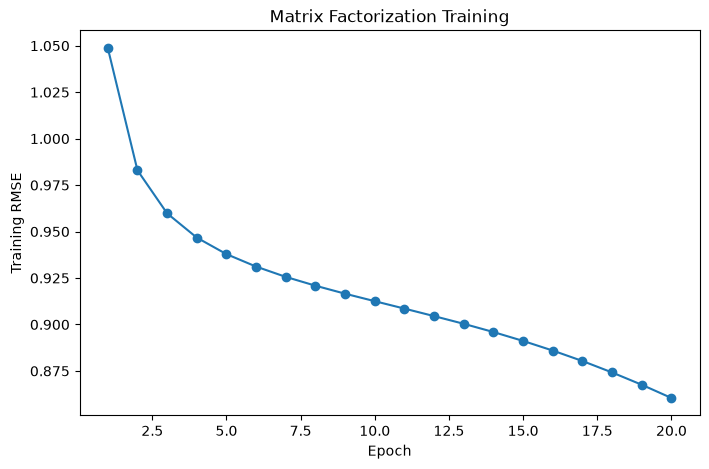

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(training_rmse) + 1),
    training_rmse,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training RMSE")
plt.title("Matrix Factorization Training")

plt.show()

In [8]:
def predict_mf(user_id, movie_id):
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return global_mean

    u = user_to_idx[user_id]
    i = movie_to_idx[movie_id]

    prediction = (
        global_mean
        + user_bias[u]
        + movie_bias[i]
        + np.dot(P[u], Q[i])
    )

    return np.clip(prediction, 1, 5)

In [9]:
mf_predictions = []

for row in test.itertuples():
    prediction = predict_mf(
        row.user_id,
        row.movie_id
    )

    mf_predictions.append(prediction)

In [10]:
mf_rmse = np.sqrt(
    mean_squared_error(
        test["rating"],
        mf_predictions
    )
)

mf_mae = mean_absolute_error(
    test["rating"],
    mf_predictions
)

print(f"Matrix Factorization RMSE: {mf_rmse:.4f}")
print(f"Matrix Factorization MAE:  {mf_mae:.4f}")

Matrix Factorization RMSE: 0.9352
Matrix Factorization MAE:  0.7363


In [11]:
factor_values = [5, 10, 20, 40, 80]

factor_results = []

for n_factors in factor_values:

    print(f"\nTraining with {n_factors} factors...")

    P, Q, user_bias, movie_bias, global_mean, training_rmse = (
        train_matrix_factorization(
            train=train,
            user_to_idx=user_to_idx,
            movie_to_idx=movie_to_idx,
            num_users=num_users,
            num_movies=num_movies,
            n_factors=n_factors,
            learning_rate=0.005,
            regularization=0.02,
            epochs=20,
            seed=42
        )
    )

    predictions = []

    for row in test.itertuples():

        u = user_to_idx[row.user_id]
        i = movie_to_idx[row.movie_id]

        prediction = (
            global_mean
            + user_bias[u]
            + movie_bias[i]
            + np.dot(P[u], Q[i])
        )

        predictions.append(
            np.clip(prediction, 1, 5)
        )

    rmse = np.sqrt(
        mean_squared_error(
            test["rating"],
            predictions
        )
    )

    mae = mean_absolute_error(
        test["rating"],
        predictions
    )

    factor_results.append({
        "Factors": n_factors,
        "RMSE": rmse,
        "MAE": mae
    })


Training with 5 factors...
Epoch  1/20 - Training RMSE: 1.0481
Epoch  2/20 - Training RMSE: 0.9837
Epoch  3/20 - Training RMSE: 0.9618
Epoch  4/20 - Training RMSE: 0.9500
Epoch  5/20 - Training RMSE: 0.9424
Epoch  6/20 - Training RMSE: 0.9369
Epoch  7/20 - Training RMSE: 0.9327
Epoch  8/20 - Training RMSE: 0.9293
Epoch  9/20 - Training RMSE: 0.9265
Epoch 10/20 - Training RMSE: 0.9241
Epoch 11/20 - Training RMSE: 0.9220
Epoch 12/20 - Training RMSE: 0.9200
Epoch 13/20 - Training RMSE: 0.9181
Epoch 14/20 - Training RMSE: 0.9162
Epoch 15/20 - Training RMSE: 0.9142
Epoch 16/20 - Training RMSE: 0.9122
Epoch 17/20 - Training RMSE: 0.9099
Epoch 18/20 - Training RMSE: 0.9076
Epoch 19/20 - Training RMSE: 0.9049
Epoch 20/20 - Training RMSE: 0.9020

Training with 10 factors...
Epoch  1/20 - Training RMSE: 1.0486
Epoch  2/20 - Training RMSE: 0.9836
Epoch  3/20 - Training RMSE: 0.9611
Epoch  4/20 - Training RMSE: 0.9489
Epoch  5/20 - Training RMSE: 0.9408
Epoch  6/20 - Training RMSE: 0.9349
Epoch  

In [12]:
factor_results_df = pd.DataFrame(factor_results)

factor_results_df

,Factors,RMSE,MAE
0,5,0.936557,0.738113
1,10,0.933087,0.735622
2,20,0.935206,0.736328
3,40,0.934267,0.734999
4,80,0.933656,0.734782


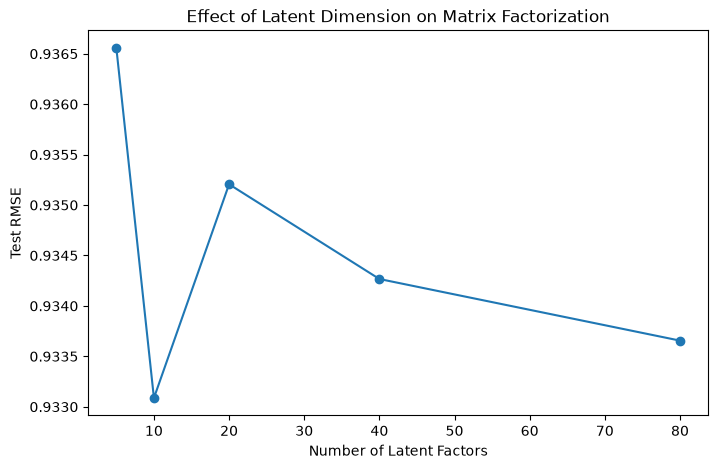

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    factor_results_df["Factors"],
    factor_results_df["RMSE"],
    marker="o"
)

plt.xlabel("Number of Latent Factors")
plt.ylabel("Test RMSE")
plt.title("Effect of Latent Dimension on Matrix Factorization")

plt.show()

In [14]:
regularization_values = [
    0.005,
    0.01,
    0.02,
    0.05,
    0.1
]

In [15]:
reg_results = []

for reg in regularization_values:

    print(f"\nTraining with regularization={reg}...")

    P, Q, user_bias, movie_bias, global_mean, training_rmse = (
        train_matrix_factorization(
            train=train,
            user_to_idx=user_to_idx,
            movie_to_idx=movie_to_idx,
            num_users=num_users,
            num_movies=num_movies,
            n_factors=10,
            learning_rate=0.005,
            regularization=reg,
            epochs=20,
            seed=42
        )
    )

    predictions = []

    for row in test.itertuples():

        u = user_to_idx[row.user_id]
        i = movie_to_idx[row.movie_id]

        prediction = (
            global_mean
            + user_bias[u]
            + movie_bias[i]
            + np.dot(P[u], Q[i])
        )

        predictions.append(
            np.clip(prediction, 1, 5)
        )

    rmse = np.sqrt(
        mean_squared_error(
            test["rating"],
            predictions
        )
    )

    mae = mean_absolute_error(
        test["rating"],
        predictions
    )

    reg_results.append({
        "Regularization": reg,
        "RMSE": rmse,
        "MAE": mae
    })


Training with regularization=0.005...
Epoch  1/20 - Training RMSE: 1.0484
Epoch  2/20 - Training RMSE: 0.9832
Epoch  3/20 - Training RMSE: 0.9606
Epoch  4/20 - Training RMSE: 0.9484
Epoch  5/20 - Training RMSE: 0.9402
Epoch  6/20 - Training RMSE: 0.9341
Epoch  7/20 - Training RMSE: 0.9292
Epoch  8/20 - Training RMSE: 0.9251
Epoch  9/20 - Training RMSE: 0.9214
Epoch 10/20 - Training RMSE: 0.9180
Epoch 11/20 - Training RMSE: 0.9146
Epoch 12/20 - Training RMSE: 0.9113
Epoch 13/20 - Training RMSE: 0.9078
Epoch 14/20 - Training RMSE: 0.9040
Epoch 15/20 - Training RMSE: 0.8998
Epoch 16/20 - Training RMSE: 0.8955
Epoch 17/20 - Training RMSE: 0.8905
Epoch 18/20 - Training RMSE: 0.8852
Epoch 19/20 - Training RMSE: 0.8795
Epoch 20/20 - Training RMSE: 0.8735

Training with regularization=0.01...
Epoch  1/20 - Training RMSE: 1.0485
Epoch  2/20 - Training RMSE: 0.9833
Epoch  3/20 - Training RMSE: 0.9608
Epoch  4/20 - Training RMSE: 0.9486
Epoch  5/20 - Training RMSE: 0.9404
Epoch  6/20 - Training 

In [16]:
reg_results_df = pd.DataFrame(reg_results)

reg_results_df

,Regularization,RMSE,MAE
0,0.005,0.933493,0.735159
1,0.010,0.933124,0.735140
2,0.020,0.933087,0.735622
3,0.050,0.935519,0.738770
4,0.100,0.939592,0.743633


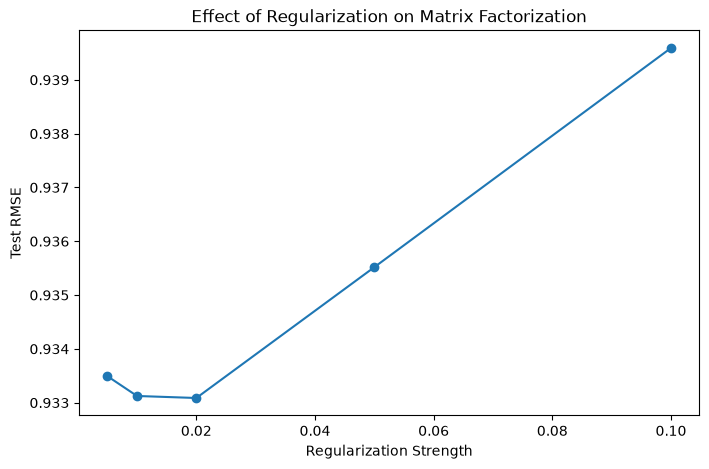

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    reg_results_df["Regularization"],
    reg_results_df["RMSE"],
    marker="o"
)

plt.xlabel("Regularization Strength")
plt.ylabel("Test RMSE")
plt.title("Effect of Regularization on Matrix Factorization")

plt.show()

## Matrix Factorization Results

Matrix factorization was implemented from scratch using stochastic gradient descent. The model represents users and movies with learned latent vectors and incorporates user and movie biases.

The initial model with 20 latent factors achieved an RMSE of approximately 0.935 and an MAE of 0.736.

Experiments with latent dimensionality showed that increasing the number of factors did not consistently improve prediction accuracy. Among the tested values, 10 latent factors produced the lowest RMSE of approximately 0.933.

Regularization values between 0.01 and 0.02 performed similarly, while stronger regularization reduced predictive performance.

The matrix factorization model performed substantially better than the simple baseline models and approximately matched the performance of mean-centered collaborative filtering.

Hyperparameter selection will be repeated using a dedicated validation set before final model evaluation to avoid selecting parameters based on test-set performance.